# Quantum Bayesian Inference Tutorial
This tutorial showcases how classical Bayesian methods can be modeled and computed within a quantum computing framework using **PennyLane**.

### Why Quantum Bayes?
In classical statistics, Bayes' theorem updates the probability for a hypothesis as more evidence or information becomes available. In quantum computing, we can represent probability distributions directly in the state space of a quantum system.
- **Qubits** represent binary random variables (Hypothesis, Data, or Features).
- **Probability amplitudes** (via rotation gates) represent probabilities.
- **Controlled gates** represent conditional probabilities (likelihoods).
- **Measurement and post-selection** represent observing the evidence and calculating the posterior probability.

In [1]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a premium styling theme
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.titlesize': 16,
    'figure.dpi': 120,
    'savefig.dpi': 120
})

# Custom premium palette
colors = {
    'primary': '#4E79A7',
    'secondary': '#E15759',
    'highlight': '#BE123C',
    'accent': '#76B7B2',
    'dark': '#1F2937',
    'light': '#F3F4F6'
}


## 1. Single Variable Bayesian Update

Let's implement a simple update using Bayes' theorem and quantum computing.

We use a two-qubit system:
* **Qubit 0** represents our **Hypothesis** ($H \in \{0, 1\}$).
* **Qubit 1** represents our **Data** ($D \in \{0, 1\}$), where $1$ means "Data observed" and $0$ means "Data not observed".

### Mathematical Formulation
Classically, Bayes' theorem states:
$$P(H = 1 \mid D = 1) = \frac{P(D = 1 \mid H = 1) P(H = 1)}{P(D = 1)}$$

Where the evidence $P(D=1)$ is calculated by marginalizing over the hypothesis:
$$P(D = 1) = P(D = 1 \mid H = 0) P(H = 0) + P(D = 1 \mid H = 1) P(H = 1)$$

### Mapping to a Quantum Circuit
1. **Prior**: We initialize the Hypothesis qubit (Wire 0) using a $Y$-rotation gate $RY(\theta_{\text{prior}})$, where $\theta_{\text{prior}} = 2 \arcsin(\sqrt{P(H=1)})$.
2. **Likelihood**: We encode the conditional probabilities (likelihoods) into the Data qubit (Wire 1):
   - If Wire 0 is $|0\rangle$, we rotate Wire 1 by $\theta_{\text{lik\_0}} = 2 \arcsin(\sqrt{P(D=1 \mid H=0)})$.
   - If Wire 0 is $|1\rangle$, we rotate Wire 1 by $\theta_{\text{lik\_1}} = 2 \arcsin(\sqrt{P(D=1 \mid H=1)})$.
3. **Posterior Calculation**: We measure the joint probabilities of both qubits. By post-selecting the states where the Data qubit is $|1\rangle$ (observing the evidence), we compute the posterior probability:
   $$P(H=1 \mid D=1) = \frac{P(1, 1)}{P(0, 1) + P(1, 1)}$$

In [2]:
import pennylane as qml
from pennylane import numpy as np

# 1. Define our classical Bayesian inputs
p_prior = 0.3          # P(Hypothesis = 1)
p_d_given_0 = 0.1      # P(Data = 1 | Hypothesis = 0)
p_d_given_1 = 0.8      # P(Data = 1 | Hypothesis = 1)

# 2. Calculate the rotation angles required for the quantum gates
# Quantum gates use angles where Probability = sin(angle/2)^2
theta_prior = 2 * np.arcsin(np.sqrt(p_prior))
theta_lik_0 = 2 * np.arcsin(np.sqrt(p_d_given_0))
theta_lik_1 = 2 * np.arcsin(np.sqrt(p_d_given_1))

# 3. Create a 2-qubit simulator
dev = qml.device("default.qubit", wires=2)

@qml.qnode(dev)
def quantum_bayes_circuit():
    # Step A: Initialize the Hypothesis qubit (Wire 0) with our Prior
    qml.RY(theta_prior, wires=0)
    
    # Step B: Encode Likelihood if Hypothesis is 0
    # (Flip wire 0, apply controlled rotation, then flip wire 0 back)
    qml.X(0)
    qml.CRY(theta_lik_0, wires=[0, 1])
    qml.X(0)
    
    # Step C: Encode Likelihood if Hypothesis is 1
    qml.CRY(theta_lik_1, wires=[0, 1])
    
    # Return the joint probability distribution of both qubits
    return qml.probs(wires=[0, 1])

# 4. Run the quantum circuit
# Output is an array mapping to states: [P(0,0), P(0,1), P(1,0), P(1,1)]
joint_probs = quantum_bayes_circuit()

# 5. Post-select for observing the Data (Data = 1, which means wire 1 is in state 1)
p_h0_and_d1 = joint_probs[1] # State |01>
p_h1_and_d1 = joint_probs[3] # State |11>

# Calculate the Quantum Posterior: P(H=1 | D=1) = P(1,1) / (P(0,1) + P(1,1))
quantum_posterior = p_h1_and_d1 / (p_h0_and_d1 + p_h1_and_d1)

# 6. Calculate classical Bayes for verification
classical_evidence = (p_d_given_0 * (1 - p_prior)) + (p_d_given_1 * p_prior)
classical_posterior = (p_d_given_1 * p_prior) / classical_evidence

# Print Results
print(f"Quantum Joint Probabilities: {joint_probs}")
print(f"Quantum Posterior P(H=1 | D=1): {quantum_posterior:.4f}")
print(f"Classical Posterior P(H=1 | D=1): {classical_posterior:.4f}")

Quantum Joint Probabilities: [0.63 0.07 0.06 0.24]
Quantum Posterior P(H=1 | D=1): 0.7742
Classical Posterior P(H=1 | D=1): 0.7742


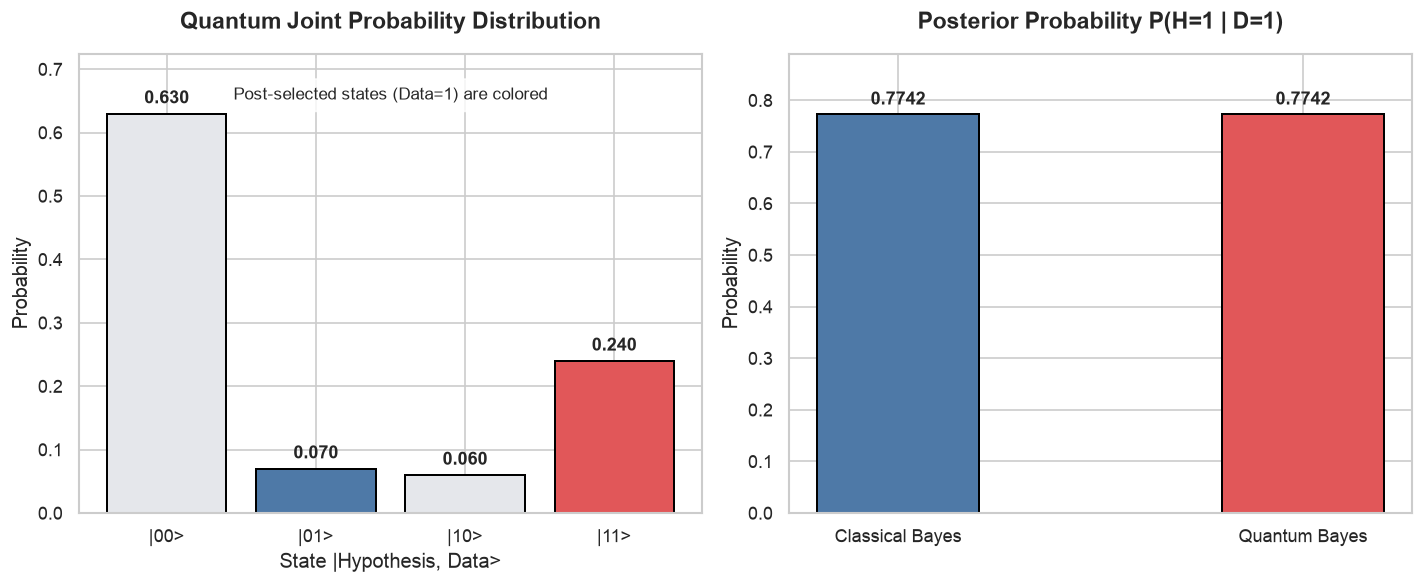

In [3]:
# Visualize Joint Probabilities and Post-selection
states = ['|00>', '|01>', '|10>', '|11>']
joint_probs_np = np.array(joint_probs)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Joint Probabilities
bars = ax1.bar(states, joint_probs_np, color=['#E5E7EB', colors['primary'], '#E5E7EB', colors['secondary']], edgecolor='black', linewidth=1.2)
ax1.set_title("Quantum Joint Probability Distribution", fontsize=14, fontweight='bold', pad=15)
ax1.set_ylabel("Probability", fontsize=12)
ax1.set_xlabel("State |Hypothesis, Data>", fontsize=12)
ax1.set_ylim(0, max(joint_probs_np) * 1.15)

# Annotate values on top of bars
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{yval:.3f}', ha='center', va='bottom', fontweight='bold')

# Add highlighting explanation
ax1.text(0.5, 0.9, "Post-selected states (Data=1) are colored", transform=ax1.transAxes, 
         bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'), fontsize=10, ha='center')

# Plot 2: Classical vs Quantum Posterior Comparison
posteriors = [classical_posterior, quantum_posterior]
labels = ['Classical Bayes', 'Quantum Bayes']
bars2 = ax2.bar(labels, posteriors, color=[colors['primary'], colors['secondary']], width=0.4, edgecolor='black', linewidth=1.2)
ax2.set_title("Posterior Probability P(H=1 | D=1)", fontsize=14, fontweight='bold', pad=15)
ax2.set_ylabel("Probability", fontsize=12)
ax2.set_ylim(0, max(posteriors) * 1.15)

for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 2. Quantum Naive Bayes Classifier

To make this significantly more interesting, let's scale it up from a single variable to a **Quantum Naive Bayes Classifier** that handles multiple features simultaneously.

In classical data science, a Naive Bayes model assumes that all features are conditionally independent given the class label. This forces you to chain multiplications together:
$$P(Y \mid X_1, X_2) \propto P(Y) \cdot P(X_1 \mid Y) \cdot P(X_2 \mid Y)$$

### Mapping to a Quantum Circuit
In a quantum circuit, we can map this entire network topology directly onto physical qubits using quantum entanglement.
- The target class ($Y$) owns its own qubit (Wire 0).
- Each feature ($X_i$) gets its own qubit (Wire 1 for $X_1$, Wire 2 for $X_2$).
- By using controlled-rotation (`CRY`) gates, the features naturally condition themselves on the target state $Y$, constructing the entire joint probability tensor simultaneously.
- We then post-select the state where both features are observed as true ($X_1 = 1$ and $X_2 = 1$). This corresponds to the quantum states $|011\rangle$ (index 3) and $|111\rangle$ (index 7).
- The normalized ratio gives the posterior:
  $$P(Y=1 \mid X_1=1, X_2=1) = \frac{P(1, 1, 1)}{P(0, 1, 1) + P(1, 1, 1)}$$

In [4]:
import pennylane as qml
from pennylane import numpy as np

# 1. Define the parameters for our Naive Bayes Network
p_prior_y = 0.4  # P(Target = 1)

# Feature 1 Likelihoods: P(X1 = 1 | Y)
p_x1_given_y0 = 0.2
p_x1_given_y1 = 0.7

# Feature 2 Likelihoods: P(X2 = 1 | Y)
p_x2_given_y0 = 0.1
p_x2_given_y1 = 0.8

# 2. Convert probabilities to quantum gate angles
theta_prior = 2 * np.arcsin(np.sqrt(p_prior_y))
theta_x1_y0 = 2 * np.arcsin(np.sqrt(p_x1_given_y0))
theta_x1_y1 = 2 * np.arcsin(np.sqrt(p_x1_given_y1))
theta_x2_y0 = 2 * np.arcsin(np.sqrt(p_x2_given_y0))
theta_x2_y1 = 2 * np.arcsin(np.sqrt(p_x2_given_y1))

# 3. Setup a 3-qubit simulator: Wire 0 = Y, Wire 1 = X1, Wire 2 = X2
dev = qml.device("default.qubit", wires=3)

@qml.qnode(dev)
def quantum_naive_bayes():
    # Step A: Load the Prior into the Target qubit (Y)
    qml.RY(theta_prior, wires=0)
    
    # Step B: Condition features on Y = 0
    qml.X(0)
    qml.CRY(theta_x1_y0, wires=[0, 1])  # X1 given Y=0
    qml.CRY(theta_x2_y0, wires=[0, 2])  # X2 given Y=0
    qml.X(0) # Flip back
    
    # Step C: Condition features on Y = 1
    qml.CRY(theta_x1_y1, wires=[0, 1])  # X1 given Y=1
    qml.CRY(theta_x2_y1, wires=[0, 2])  # X2 given Y=1
    
    # Return the joint probabilities of the entire 3-qubit system
    return qml.probs(wires=[0, 1, 2])

# 4. Run the network to get the joint probability array
# The output maps to 8 binary states: [000, 001, 010, 011, 100, 101, 110, 111]
joint_probs = quantum_naive_bayes()

# 5. Post-selection: Assume we observed both features as true (X1 = 1, X2 = 1)
# State 011 (Y=0, X1=1, X2=1) is index 3
# State 111 (Y=1, X1=1, X2=1) is index 7
p_y0_and_features_true = joint_probs[3]
p_y1_and_features_true = joint_probs[7]

# Normalize to find the posterior: P(Y=1 | X1=1, X2=1)
quantum_posterior = p_y1_and_features_true / (p_y0_and_features_true + p_y1_and_features_true)

# 6. Verify classically
classical_numerator = p_prior_y * p_x1_given_y1 * p_x2_given_y1
classical_evidence = (p_prior_y * p_x1_given_y1 * p_x2_given_y1) + ((1 - p_prior_y) * p_x1_given_y0 * p_x2_given_y0)
classical_posterior = classical_numerator / classical_evidence

print(f"Quantum Posterior P(Y=1 | X1=1, X2=1): {quantum_posterior:.4f}")
print(f"Classical Posterior P(Y=1 | X1=1, X2=1): {classical_posterior:.4f}")

Quantum Posterior P(Y=1 | X1=1, X2=1): 0.9492
Classical Posterior P(Y=1 | X1=1, X2=1): 0.9492


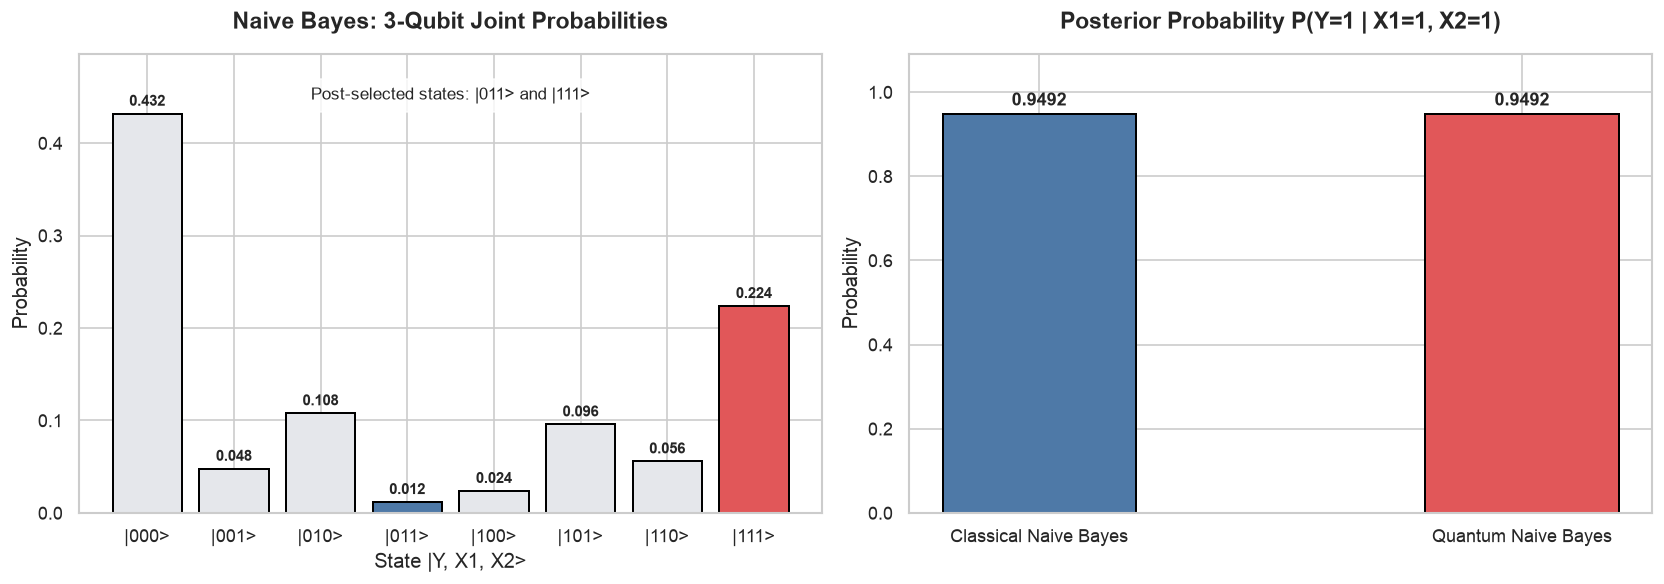

In [5]:
# Visualize Joint Probabilities for Naive Bayes
states_nb = ['|000>', '|001>', '|010>', '|011>', '|100>', '|101>', '|110>', '|111>']
joint_probs_nb_np = np.array(joint_probs)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: 8-state Joint Probability Distribution
colors_list = ['#E5E7EB'] * 8
colors_list[3] = colors['primary'] # |011>
colors_list[7] = colors['secondary'] # |111>

bars_nb = ax1.bar(states_nb, joint_probs_nb_np, color=colors_list, edgecolor='black', linewidth=1.2)
ax1.set_title("Naive Bayes: 3-Qubit Joint Probabilities", fontsize=14, fontweight='bold', pad=15)
ax1.set_ylabel("Probability", fontsize=12)
ax1.set_xlabel("State |Y, X1, X2>", fontsize=12)
ax1.set_ylim(0, max(joint_probs_nb_np) * 1.15)

for bar in bars_nb:
    yval = bar.get_height()
    if yval > 0.01:
        ax1.text(bar.get_x() + bar.get_width()/2.0, yval + 0.005, f'{yval:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Highlight post-selection in the text
ax1.text(0.5, 0.9, "Post-selected states: |011> and |111>", 
         transform=ax1.transAxes, bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'), fontsize=10, ha='center')

# Plot 2: Posterior Comparison
posteriors_nb = [classical_posterior, quantum_posterior]
labels_nb = ['Classical Naive Bayes', 'Quantum Naive Bayes']
bars2_nb = ax2.bar(labels_nb, posteriors_nb, color=[colors['primary'], colors['secondary']], width=0.4, edgecolor='black', linewidth=1.2)
ax2.set_title("Posterior Probability P(Y=1 | X1=1, X2=1)", fontsize=14, fontweight='bold', pad=15)
ax2.set_ylabel("Probability", fontsize=12)
ax2.set_ylim(0, max(posteriors_nb) * 1.15)

for bar in bars2_nb:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Bayesian Optimization for VQAs / Hybrid Learning

This flips the script: instead of using quantum to help Bayes, we use classical Bayesian methods to solve a massive quantum problem.

Training a Variational Quantum Circuit (VQC) or a Quantum Neural Network (QNN) requires tuning continuous parameters (like the rotation angles of quantum gates). Because physical quantum hardware is noisy and expensive to sample, we cannot afford to run millions of gradient steps.

### How it applies
Data scientists use classical **Bayesian Optimization** to build a probabilistic surrogate model of the quantum circuit's objective function (usually a Gaussian Process).
* The surrogate model maps the gate parameters to the expected energy/cost.
* An **Acquisition Function** (like Lower Confidence Bound: $\text{LCB}(\theta) = \mu(\theta) - \kappa \cdot \sigma(\theta)$) is evaluated classically to decide the next best parameter value to test on the quantum hardware.
* This allows you to train complex quantum machine learning models using a fraction of the hardware runs required by traditional gradient descent.

Below, we simulate a simple VQA objective function: minimizing the expectation value $\langle Z \rangle$ of a rotated qubit, under simulated hardware noise:
$$f(\theta) = \cos(\theta) + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \sigma_{\text{noise}}^2)$$
We will compare a custom Gaussian Process Bayesian Optimization loop against Standard Gradient Descent.

In [6]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
import warnings
warnings.filterwarnings('ignore')

# 1. Define noisy quantum target function in PennyLane
dev_vqa = qml.device("default.qubit", wires=1)

@qml.qnode(dev_vqa)
def circuit_vqa(theta):
    qml.RY(theta, wires=0)
    return qml.expval(qml.PauliZ(0))

# Noisy evaluation function
noise_level = 0.15
def objective_noisy(theta_val):
    # Expectation value of RY(theta) on PauliZ is cos(theta). Ground state is at theta = pi (value = -1)
    # We evaluate the quantum circuit and add simulated hardware noise
    return float(circuit_vqa(theta_val)) + np.random.normal(0, noise_level)

# 2. Bayesian Optimization setup
np.random.seed(42)
# We start with 3 initial random evaluations of the quantum circuit
X_bo = list(np.random.uniform(0, 2 * np.pi, 3))
y_bo = [objective_noisy(x) for x in X_bo]

# Gaussian Process surrogate model with an RBF kernel
gp = GaussianProcessRegressor(
    kernel=C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2)),
    alpha=noise_level**2, # noise variance
    n_restarts_optimizer=10,
    random_state=42
)

# Custom LCB acquisition function
def lcb_acquisition(x_grid, gp_model, kappa=1.5):
    mu, sigma = gp_model.predict(x_grid.reshape(-1, 1), return_std=True)
    return mu - kappa * sigma

# Run Bayesian Optimization for 10 iterations
n_bo_iters = 10
grid = np.linspace(0, 2 * np.pi, 200)

for i in range(n_bo_iters):
    # Fit GP model on observed data
    gp.fit(np.array(X_bo).reshape(-1, 1), np.array(y_bo))
    
    # Evaluate acquisition function on grid
    acq_values = lcb_acquisition(grid, gp)
    
    # Select next query point (minimizing LCB)
    next_x = grid[np.argmin(acq_values)]
    next_y = objective_noisy(next_x)
    
    X_bo.append(next_x)
    y_bo.append(next_y)

# Fit final GP model
gp.fit(np.array(X_bo).reshape(-1, 1), np.array(y_bo))

# 3. Baseline: Gradient Descent (under same noise level)
# We implement a simple finite-difference gradient estimation to simulate parameter-shift style gradients
X_gd = [X_bo[0]] # start from same first random point
y_gd = [y_bo[0]]

lr = 0.5
theta_curr = X_gd[0]

for i in range(n_bo_iters):
    # Finite-difference gradient with step size eps
    eps = 0.05
    y_plus = objective_noisy(theta_curr + eps)
    y_minus = objective_noisy(theta_curr - eps)
    grad = (y_plus - y_minus) / (2 * eps)
    
    # Update parameter
    theta_curr = theta_curr - lr * grad
    # Clip parameter to our bounds [0, 2*pi]
    theta_curr = np.clip(theta_curr, 0, 2 * np.pi)
    
    val = objective_noisy(theta_curr)
    X_gd.append(theta_curr)
    y_gd.append(val)

# Best values found at each evaluation step
best_bo = [min(y_bo[:i+1]) for i in range(len(y_bo))]
best_gd = [min(y_gd[:i+1]) for i in range(len(y_gd))]

print(f"Bayesian Optimization Best Angle: {X_bo[np.argmin(y_bo)]:.4f} (value: {min(y_bo):.4f})")
print(f"Gradient Descent Best Angle: {X_gd[np.argmin(y_gd)]:.4f} (value: {min(y_gd):.4f})")

Bayesian Optimization Best Angle: 3.1890 (value: -1.3908)
Gradient Descent Best Angle: 2.7370 (value: -1.2402)


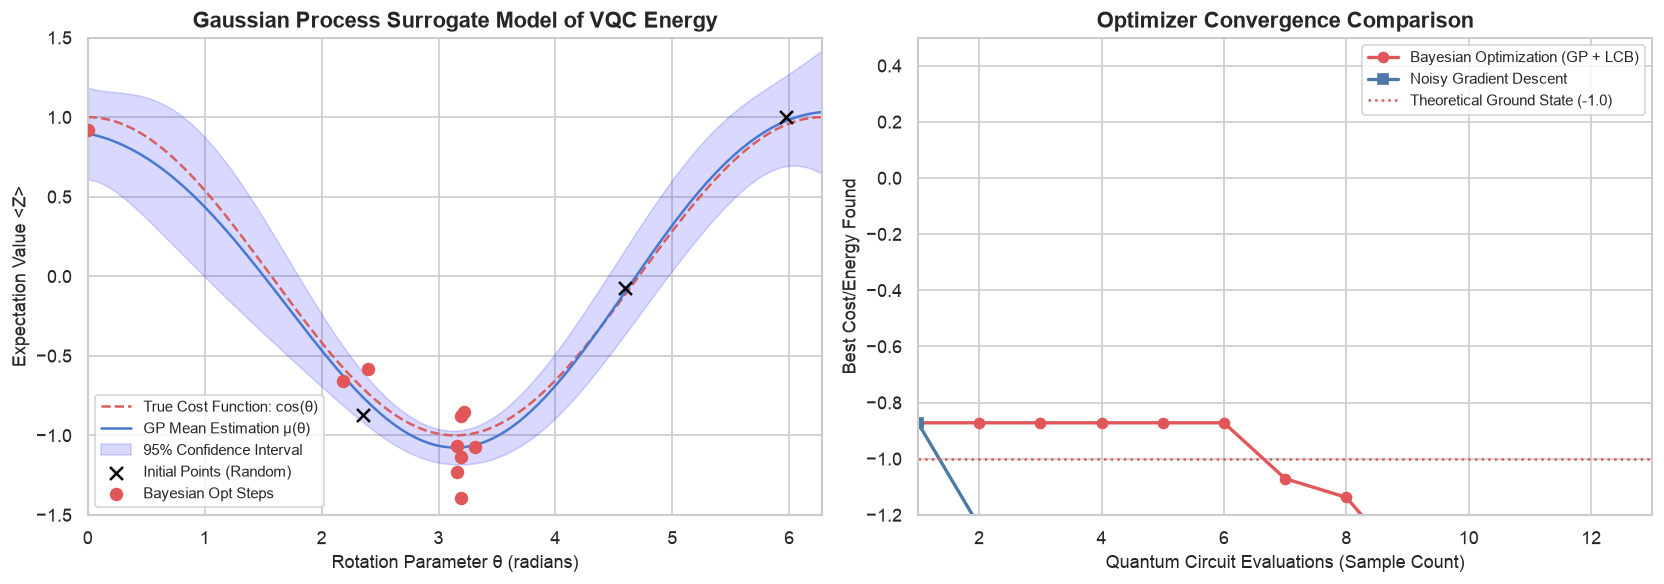

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: GP Surrogate Model and Evaluated Points
x_plot = np.linspace(0, 2 * np.pi, 200)
y_true = np.cos(x_plot)
mu_gp, sigma_gp = gp.predict(x_plot.reshape(-1, 1), return_std=True)

ax1.plot(x_plot, y_true, 'r--', label='True Cost Function: cos(θ)', linewidth=1.5)
ax1.plot(x_plot, mu_gp, 'b-', label='GP Mean Estimation μ(θ)', linewidth=1.5)
ax1.fill_between(x_plot, mu_gp - 1.96 * sigma_gp, mu_gp + 1.96 * sigma_gp, alpha=0.15, color='blue', label='95% Confidence Interval')

# Differentiate initial vs optimized points
ax1.scatter(X_bo[:3], y_bo[:3], color='black', marker='x', s=60, label='Initial Points (Random)', zorder=5)
ax1.scatter(X_bo[3:], y_bo[3:], color=colors['secondary'], marker='o', s=50, label='Bayesian Opt Steps', zorder=5)

ax1.set_title("Gaussian Process Surrogate Model of VQC Energy", fontsize=13, fontweight='bold')
ax1.set_xlabel("Rotation Parameter θ (radians)", fontsize=11)
ax1.set_ylabel("Expectation Value <Z>", fontsize=11)
ax1.set_xlim(0, 2 * np.pi)
ax1.set_ylim(-1.5, 1.5)
ax1.legend(loc='lower left', frameon=True, fontsize=9)

# Plot 2: Convergence Comparison (Best Value vs Evaluations)
evals_bo = range(1, len(best_bo) + 1)
evals_gd = range(1, len(best_gd) + 1)

ax2.plot(evals_bo, best_bo, color=colors['secondary'], marker='o', label='Bayesian Optimization (GP + LCB)', linewidth=2)
ax2.plot(evals_gd, best_gd, color=colors['primary'], marker='s', label='Noisy Gradient Descent', linewidth=2)
ax2.axhline(-1.0, color='r', linestyle=':', label='Theoretical Ground State (-1.0)')

ax2.set_title("Optimizer Convergence Comparison", fontsize=13, fontweight='bold')
ax2.set_xlabel("Quantum Circuit Evaluations (Sample Count)", fontsize=11)
ax2.set_ylabel("Best Cost/Energy Found", fontsize=11)
ax2.set_xlim(1, max(len(best_bo), len(best_gd)))
ax2.set_ylim(-1.2, 0.5)
ax2.legend(loc='upper right', frameon=True, fontsize=9)

plt.tight_layout()
plt.show()

## 4. Quantum Bayesian Networks (QBNs)

In classical data science, a Bayesian Network uses a Directed Acyclic Graph (DAG) and Conditional Probability Tables (CPTs) to map out dependencies. A QBN replaces those rigid classical probabilities with quantum probability amplitudes.

* **The Superpower**: Because qubits can exist in a superposition, a QBN can model and process vastly more simultaneous hidden states than a classical network.
* **The Quantum Edge**: It uses quantum entanglement to model complex, non-local correlations and causal links that completely defy classical probability calculus.

### Classical Network Structure: Rain-Sprinkler-Wet Grass
We'll implement the standard Rain-Sprinkler-Wet Grass DAG:
* **Rain ($R$)** has no parents: $P(R=1) = 0.2$
* **Sprinkler ($S$)** depends on $R$:
  * $P(S=1 \mid R=0) = 0.4$
  * $P(S=1 \mid R=1) = 0.01$
* **Wet Grass ($W$)** depends on both $R$ and $S$:
  * $P(W=1 \mid R=0, S=0) = 0.0$
  * $P(W=1 \mid R=0, S=1) = 0.8$
  * $P(W=1 \mid R=1, S=0) = 0.9$
  * $P(W=1 \mid R=1, S=1) = 0.99$

### Mapping to Multi-Controlled Gates
In our quantum circuit:
* **Wire 0** is Rain ($R$).
* **Wire 1** is Sprinkler ($S$).
* **Wire 2** is Wet Grass ($W$).

We initialize $R$, condition $S$ using controlled rotation (`CRY`) gates, and condition $W$ on the joint state of $R$ and $S$ using multi-controlled rotation gates (`qml.ctrl(qml.RY, control=[0, 1])`).
We then compute the posterior probability of Rain given that the grass is observed to be Wet: $P(R=1 \mid W=1)$.

In [8]:
# 1. Define CPT probabilities
p_rain = 0.2

# Sprinkler CPT: P(S=1 | R)
p_s_given_r0 = 0.4
p_s_given_r1 = 0.01

# Wet Grass CPT: P(W=1 | R, S)
p_w_given_r0_s0 = 0.0
p_w_given_r0_s1 = 0.8
p_w_given_r1_s0 = 0.9
p_w_given_r1_s1 = 0.99

# 2. Convert to rotation angles
theta_r = 2 * np.arcsin(np.sqrt(p_rain))

theta_s_r0 = 2 * np.arcsin(np.sqrt(p_s_given_r0))
theta_s_r1 = 2 * np.arcsin(np.sqrt(p_s_given_r1))

theta_w_00 = 2 * np.arcsin(np.sqrt(p_w_given_r0_s0))
theta_w_01 = 2 * np.arcsin(np.sqrt(p_w_given_r0_s1))
theta_w_10 = 2 * np.arcsin(np.sqrt(p_w_given_r1_s0))
theta_w_11 = 2 * np.arcsin(np.sqrt(p_w_given_r1_s1))

# 3. Create a 3-qubit simulator: Wire 0 = R, Wire 1 = S, Wire 2 = W
dev_qbn = qml.device("default.qubit", wires=3)

@qml.qnode(dev_qbn)
def quantum_bayesian_network():
    # Node R (Rain)
    qml.RY(theta_r, wires=0)
    
    # Node S (Sprinkler) conditioned on R
    qml.X(0)
    qml.CRY(theta_s_r0, wires=[0, 1])
    qml.X(0)
    qml.CRY(theta_s_r1, wires=[0, 1])
    
    # Node W (Wet Grass) conditioned on R and S
    # State |00>: No Rain, No Sprinkler
    qml.X(0)
    qml.X(1)
    qml.ctrl(qml.RY, control=[0, 1])(theta_w_00, wires=2)
    qml.X(1)
    qml.X(0)
    
    # State |01>: No Rain, Sprinkler
    qml.X(0)
    qml.ctrl(qml.RY, control=[0, 1])(theta_w_01, wires=2)
    qml.X(0)
    
    # State |10>: Rain, No Sprinkler
    qml.X(1)
    qml.ctrl(qml.RY, control=[0, 1])(theta_w_10, wires=2)
    qml.X(1)
    
    # State |11>: Rain, Sprinkler
    qml.ctrl(qml.RY, control=[0, 1])(theta_w_11, wires=2)
    
    return qml.probs(wires=[0, 1, 2])

# 4. Run the QBN
# Returns 8 joint probabilities: [P(000), P(001), P(010), P(011), P(100), P(101), P(110), P(111)]
# States mapped as: |R, S, W>
joint_probs_qbn = quantum_bayesian_network()

# 5. Post-selection: We observe that the grass is wet (W=1)
# Wet Grass corresponds to states where the third bit is 1: |001> (idx 1), |011> (idx 3), |101> (idx 5), |111> (idx 7)
p_w1_states = [joint_probs_qbn[1], joint_probs_qbn[3], joint_probs_qbn[5], joint_probs_qbn[7]]
total_evidence_w1 = sum(p_w1_states)

# We want the posterior of Rain (R=1), which corresponds to |101> (idx 5) and |111> (idx 7)
p_rain_and_w1 = joint_probs_qbn[5] + joint_probs_qbn[7]
quantum_posterior_qbn = p_rain_and_w1 / total_evidence_w1

# 6. Verify classically
# P(R, S, W) = P(R) * P(S|R) * P(W|R,S)
p_r0 = 1 - p_rain
p_r1 = p_rain

p_r0_s0_w1 = p_r0 * (1 - p_s_given_r0) * p_w_given_r0_s0
p_r0_s1_w1 = p_r0 * p_s_given_r0 * p_w_given_r0_s1
p_r1_s0_w1 = p_r1 * (1 - p_s_given_r1) * p_w_given_r1_s0
p_r1_s1_w1 = p_r1 * p_s_given_r1 * p_w_given_r1_s1

classical_evidence_w1 = p_r0_s0_w1 + p_r0_s1_w1 + p_r1_s0_w1 + p_r1_s1_w1
classical_posterior_qbn = (p_r1_s0_w1 + p_r1_s1_w1) / classical_evidence_w1

print(f"Quantum Joint Probabilities: {joint_probs_qbn}")
print(f"Quantum Posterior P(Rain=1 | Grass=Wet): {quantum_posterior_qbn:.4f}")
print(f"Classical Posterior P(Rain=1 | Grass=Wet): {classical_posterior_qbn:.4f}")

Quantum Joint Probabilities: [4.800e-01 0.000e+00 6.400e-02 2.560e-01 1.980e-02 1.782e-01 2.000e-05
 1.980e-03]
Quantum Posterior P(Rain=1 | Grass=Wet): 0.4131
Classical Posterior P(Rain=1 | Grass=Wet): 0.4131


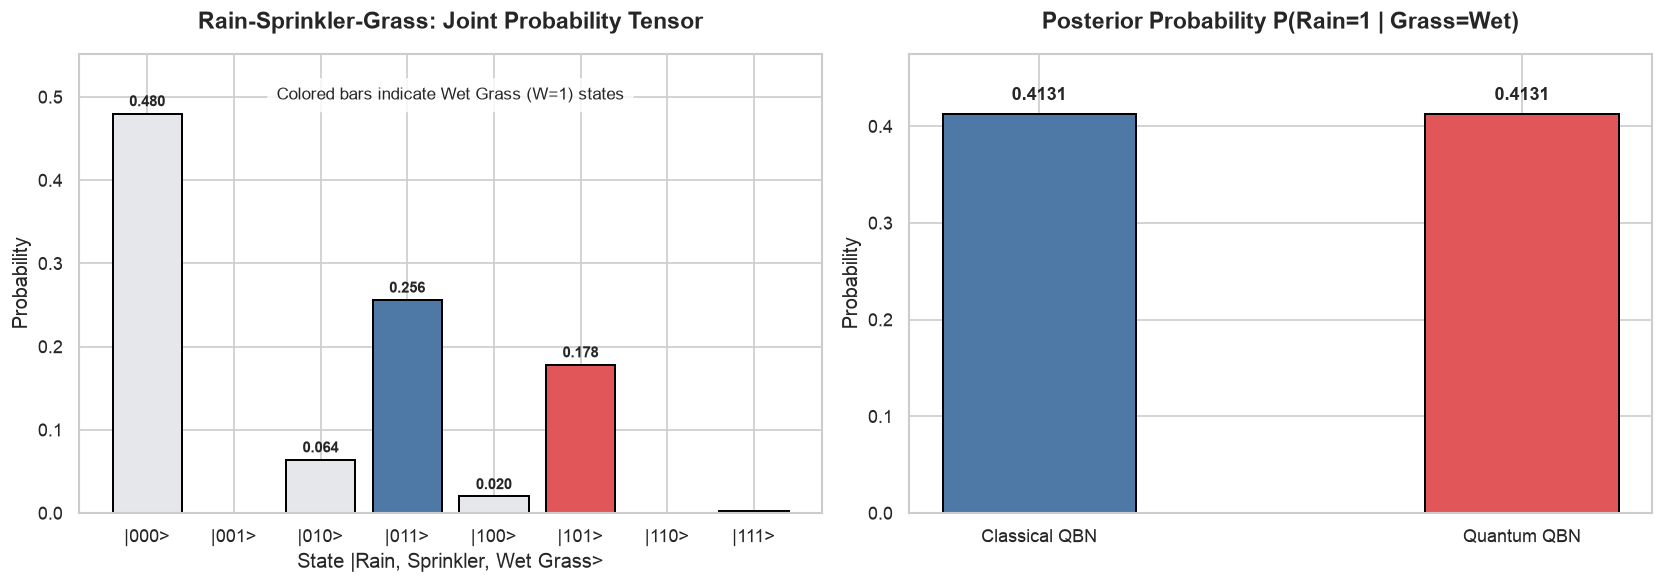

In [9]:
# Visualize Joint Probabilities and Post-selection for QBN
states_qbn = ['|000>', '|001>', '|010>', '|011>', '|100>', '|101>', '|110>', '|111>']
joint_probs_qbn_np = np.array(joint_probs_qbn)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: 8-state Joint Probability Distribution
colors_list = ['#E5E7EB'] * 8
# Highlight states where Grass is Wet (W=1)
colors_list[1] = colors['accent']      # |001>
colors_list[3] = colors['primary']     # |011>
colors_list[5] = colors['secondary']   # |101>
colors_list[7] = colors['highlight']   # |111>

bars_qbn = ax1.bar(states_qbn, joint_probs_qbn_np, color=colors_list, edgecolor='black', linewidth=1.2)
ax1.set_title("Rain-Sprinkler-Grass: Joint Probability Tensor", fontsize=14, fontweight='bold', pad=15)
ax1.set_ylabel("Probability", fontsize=12)
ax1.set_xlabel("State |Rain, Sprinkler, Wet Grass>", fontsize=12)
ax1.set_ylim(0, max(joint_probs_qbn_np) * 1.15)

for bar in bars_qbn:
    yval = bar.get_height()
    if yval > 0.005:
        ax1.text(bar.get_x() + bar.get_width()/2.0, yval + 0.005, f'{yval:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Highlight post-selection in the text
ax1.text(0.5, 0.9, "Colored bars indicate Wet Grass (W=1) states", 
         transform=ax1.transAxes, bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'), fontsize=10, ha='center')

# Plot 2: Posterior Comparison
posteriors_qbn = [classical_posterior_qbn, quantum_posterior_qbn]
labels_qbn = ['Classical QBN', 'Quantum QBN']
bars2_qbn = ax2.bar(labels_qbn, posteriors_qbn, color=[colors['primary'], colors['secondary']], width=0.4, edgecolor='black', linewidth=1.2)
ax2.set_title("Posterior Probability P(Rain=1 | Grass=Wet)", fontsize=14, fontweight='bold', pad=15)
ax2.set_ylabel("Probability", fontsize=12)
ax2.set_ylim(0, max(posteriors_qbn) * 1.15)

for bar in bars2_qbn:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Adaptive Bayesian Metrology (Phase Estimation)

Quantum metrology uses quantum mechanics to achieve high-precision measurements of physical parameters. Here, we estimate an unknown phase $\phi \in [0, 2\pi]$ (for example, representing a magnetic field strength or a path length shift) using a 1-qubit quantum sensor.

### Interferometer Setup
We prepare a qubit in the superposition state $|+\rangle = \frac{1}{\sqrt{2}}(|0
angle + |1
angle)$, apply the unknown phase shift $\phi$, and then apply a classical control phase adjustment $-\theta$. The state becomes:
$$|\psi\rangle = \frac{1}{\sqrt{2}} \left( |0\rangle + e^{i(\phi - \theta)} |1\rangle \right)$$

Measuring in the $X$-basis (by applying a Hadamard gate followed by computational measurement) yields:
* **Outcome $0$** with probability: $P(0 \mid \phi, \theta) = \frac{1 + \cos(\phi - \theta)}{2}$
* **Outcome $1$** with probability: $P(1 \mid \phi, \theta) = \frac{1 - \cos(\phi - \theta)}{2}$

### Adaptive Bayesian Update Loop
We represent our uncertainty about $\phi$ as a probability distribution $P(\phi)$ over a discrete grid of 100 candidate phases between $0$ and $2\pi$.
1. **Prior**: We start with a flat uniform prior: $P(\phi) = \frac{1}{N}$.
2. **Adaptive Control**: At each step $t$, we read the current estimate $\phi_{\text{est}}$ (the peak of $P(\phi)$). We set the control phase to:
   $$\theta_t = \phi_{\text{est}} + \delta_t$$
   where $\delta_t \in \{0, \pi/2\}$ is alternated. This offset maximizes the measurement sensitivity (as the derivative of $\cos(\phi - \theta)$ is highest when the argument is near $\pi/2$) and breaks phase symmetry (resolving the $\pm(\phi - \theta)$ ambiguity).
3. **Measurement**: We run the quantum circuit with parameters $\phi_{\text{true}}$ and $\theta_t$, and obtain a single-shot outcome $m_t \in \{0, 1\}$.
4. **Bayesian Update**: Using Bayes' rule, we update the distribution for all candidate values:
   $$P(\phi) \leftarrow P(m_t \mid \phi, \theta_t) \cdot P(\phi)$$
   and normalize the distribution.
5. **Repeat**: Over several steps, the wide distribution collapses into a sharp spike centered on the true phase.

In [10]:
# 1. Define the 1-qubit metrology circuit in PennyLane
dev_metrology = qml.device("default.qubit", wires=1)

@qml.qnode(dev_metrology)
def metrology_circuit(phi_true, theta):
    # Prepare state |+>
    qml.Hadamard(wires=0)
    
    # Apply unknown phase shift
    qml.PhaseShift(phi_true, wires=0)
    
    # Apply classical feedback phase adjustment
    qml.PhaseShift(-theta, wires=0)
    
    # Measure in X basis (Hadamard + computational measurement)
    qml.Hadamard(wires=0)
    return qml.probs(wires=0)

# 2. Setup the simulation
np.random.seed(42)
phi_true = 4.2  # The true, unknown phase we want to estimate
grid_size = 100
phi_grid = np.linspace(0, 2 * np.pi, grid_size)

# Uniform flat prior
p_phi = np.ones(grid_size) / grid_size

# History to store distributions for plotting
bo_history = {0: p_phi.copy()}

# Number of iterations
n_steps = 15

# 3. Run the adaptive loop
for t in range(1, n_steps + 1):
    # Find current peak estimate
    phi_est = phi_grid[np.argmax(p_phi)]
    
    # Alternate phase offset to break symmetry and maximize sensitivity
    delta = 0 if t % 2 == 0 else np.pi / 2
    theta_t = phi_est + delta
    
    # Get expectation probabilities from the quantum sensor
    probs = metrology_circuit(phi_true, theta_t)
    
    # Draw a single shot measurement from the distribution
    m_t = np.random.choice([0, 1], p=probs)
    
    # Update probabilities classically using Bayes' rule
    if m_t == 0:
        likelihood = (1 + np.cos(phi_grid - theta_t)) / 2
    else:
        likelihood = (1 - np.cos(phi_grid - theta_t)) / 2
        
    p_phi = likelihood * p_phi
    p_phi /= np.sum(p_phi)  # Normalize
    
    # Save snapshot of specific steps for visualization
    if t in [3, 7, 11, 15]:
        bo_history[t] = p_phi.copy()

print(f"True Phase: {phi_true:.4f} rad")
print(f"Estimated Phase: {phi_grid[np.argmax(p_phi)]:.4f} rad")
print(f"Absolute Estimation Error: {abs(phi_true - phi_grid[np.argmax(p_phi)]):.4f} rad")

True Phase: 4.2000 rad
Estimated Phase: 3.9984 rad
Absolute Estimation Error: 0.2016 rad


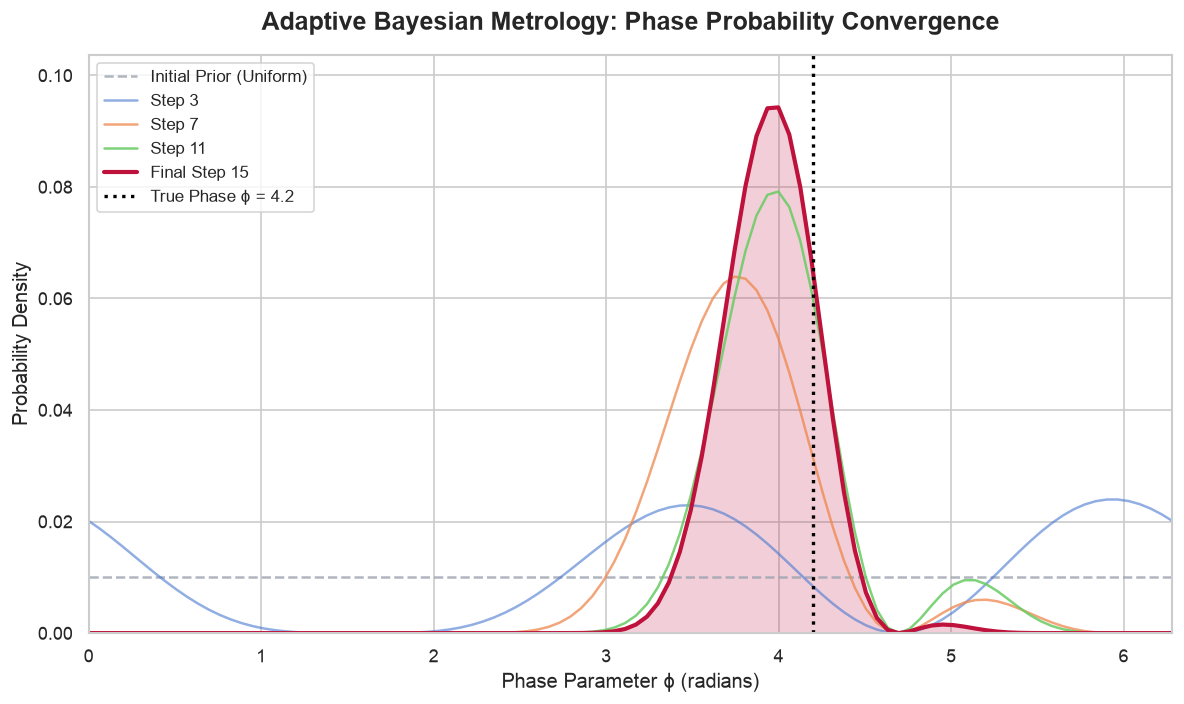

In [11]:
# Plot the evolution of the probability distribution
plt.figure(figsize=(10, 6))

# Plot snapshots
for step, dist in bo_history.items():
    if step == 0:
        plt.plot(phi_grid, dist, '--', color='#9CA3AF', label="Initial Prior (Uniform)", alpha=0.8)
    elif step == 15:
        plt.plot(phi_grid, dist, color=colors['highlight'], label=f"Final Step {step}", linewidth=2.5)
        plt.fill_between(phi_grid, dist, alpha=0.2, color=colors['highlight'])
    else:
        alpha_val = 0.5 + 0.1 * step / 3.0
        alpha_val = min(max(alpha_val, 0.3), 0.9)
        plt.plot(phi_grid, dist, label=f"Step {step}", alpha=alpha_val)

# Highlight the true phase
plt.axvline(phi_true, color='black', linestyle=':', linewidth=2, label=f"True Phase ϕ = {phi_true}")

plt.title("Adaptive Bayesian Metrology: Phase Probability Convergence", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Phase Parameter ϕ (radians)", fontsize=12)
plt.ylabel("Probability Density", fontsize=12)
plt.xlim(0, 2 * np.pi)
plt.ylim(0, max(bo_history[15]) * 1.1)
plt.legend(frameon=True, fontsize=10, loc='upper left')
plt.tight_layout()
plt.show()